In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, lil_matrix
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import pyreadr 
from pathlib import Path
import os

os.chdir(Path.cwd().parent)


S = 1601, T = 2704
Total neighbor links = 5524
Observed Moran's I = 0.8823
Posterior samples M = 1000

Running BYM Moran's I PPC...


BYM Moran PPC: 100%|██████████| 1000/1000 [09:12<00:00,  1.81it/s]



Running IID Moran's I PPC...


IID Moran PPC: 100%|██████████| 1000/1000 [07:12<00:00,  2.31it/s]



MORAN'S I PPC (TIME-AVERAGED PROPORTIONS)
Observed Moran's I = 0.8823

BYM Model:
  Mean I_pred     = 0.8836
  SD I_pred       = 0.0006
  95% CI          = [0.8824, 0.8848]
  P-value (I≥obs) = 0.9870

IID Model:
  Mean I_pred     = 0.8813
  SD I_pred       = 0.0008
  95% CI          = [0.8798, 0.8827]
  P-value (I≥obs) = 0.0980

Interpretation:
  BYM: Observed spatial autocorrelation is significantly WEAKER than model predicts
       → Model may be OVER-smoothing spatially
  IID: Model captures spatial autocorrelation well (surprising for IID model)

Results saved to: D:\77\Research\temp\snow\ppc_moran_timeavg_corrected.npz
Visualization saved to: D:\77\Research\temp\snow\ppc_moran_histogram_corrected.png


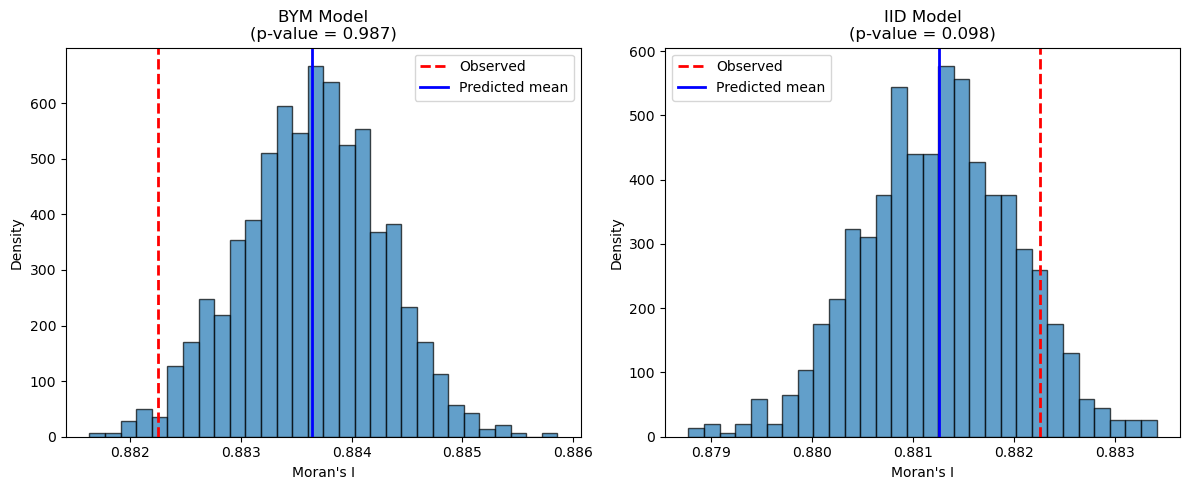

In [3]:
# ================================================================
# PPC: Moran's I for time-averaged snow proportions
# Spatial adjacency EXACTLY as in BYM construction
# CORRECTED VERSION: Simulates replicated datasets
# ================================================================

import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
import geopandas as gpd
import pyreadr
from pathlib import Path

# ================================================================
# 0. CONFIG
# ================================================================

BASE_DIR = Path(r"D:\77\Research\temp\snow")
period = 52

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ================================================================
# 1. LOAD DATA (NON-ISOLATED ONLY)
# ================================================================

snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)

keep_idx = np.setdiff1d(
    np.arange(snow.shape[0]),
    no_nbs
)

# snow indicator: (S, T)
y = snow.iloc[keep_idx, 2:].to_numpy()

# coordinates: (S, 2)
coords = snow.iloc[keep_idx, :2].to_numpy()

S, T = y.shape
print(f"S = {S}, T = {T}")

# ================================================================
# 2. BUILD SPATIAL ADJACENCY (IDENTICAL TO BYM)
# ================================================================

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords[:,0], coords[:,1]),
    crs="EPSG:4326"
)

gdf_aeqd = gdf.to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")
xy = np.vstack([gdf_aeqd.geometry.x, gdf_aeqd.geometry.y]).T

# rotation (keep same)
dif = xy[1] - xy[2]
theta = np.arctan2(dif[1], dif[0])

Rmat = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

rotated = (xy @ Rmat.T) / 1e6

Distances = squareform(pdist(rotated))

# adjacency threshold
W = (Distances <= 0.22).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

w_sum = W.sum()
print(f"Total neighbor links = {w_sum}")

# ================================================================
# 3. OBSERVED MORAN'S I (TIME-AVERAGED PROPORTION)
# ================================================================

# exclude t = 1 (conditional-on)
y_bar = y[:, 1:].mean(axis=1)

y_bar_c = y_bar - y_bar.mean()

num = y_bar_c @ (W @ y_bar_c)
den = y_bar_c @ y_bar_c

I_obs = (S / w_sum) * (num / den)

print(f"Observed Moran's I = {I_obs:.4f}")

# ================================================================
# 4. LOAD POSTERIOR SAMPLES
# ================================================================

bym01 = np.load(BASE_DIR / "bym01_noIso_final.npz")["all_theta"]
bym10 = np.load(BASE_DIR / "bym10_noIso_final.npz")["all_theta"]

ind01_full = np.load(BASE_DIR / "ind01.npz")["all_theta"]
ind10_full = np.load(BASE_DIR / "ind10.npz")["all_theta"]

# Extract non-isolated IID parameters
S_full = snow.shape[0]
K_iid = 4

ind01 = np.zeros((K_iid * S, bym01.shape[1]))
ind10 = np.zeros((K_iid * S, bym01.shape[1]))

for k in range(K_iid):
    # Take only non-isolated locations
    ind01[k*S:(k+1)*S, :] = ind01_full[k*S_full : k*S_full + S, :]
    ind10[k*S:(k+1)*S, :] = ind10_full[k*S_full : k*S_full + S, :]

M = bym01.shape[1]
print(f"Posterior samples M = {M}")

# ================================================================
# 5. BUILD TIME COVARIATES
# ================================================================
t_raw = np.arange(1, T + 1)

# IMPORTANT: same scaling rule as in run_bym()
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

# BYM covariates (8 columns)
cov_bym = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw/period), np.cos(2*np.pi*t_raw/period),
    np.sin(2*np.pi*t_raw/period), np.sin(2*np.pi*t_raw/period),
    t_trend, t_trend
])

# IID uses single set
cov_iid = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw/period),
    np.sin(2*np.pi*t_raw/period),
    t_raw
])   # (T, 4)

# ================================================================
# 6. BYM: POSTERIOR PREDICTIVE MORAN'S I (CORRECTED)
# ================================================================

print("\nRunning BYM Moran's I PPC...")
I_pred_bym = np.zeros(M)

for m in tqdm(range(M), desc="BYM Moran PPC"):
    
    # Initialize replicated dataset
    y_rep = np.zeros((S, T), dtype=int)
    y_rep[:, 0] = y[:, 0]  # use observed initial state
    
    # Simulate forward in time
    for t in range(1, T):
        
        eta01 = np.zeros(S)
        eta10 = np.zeros(S)

        for k in range(8):
            eta01 += cov_bym[t, k] * bym01[k*S:(k+1)*S, m]
            eta10 += cov_bym[t, k] * bym10[k*S:(k+1)*S, m]

        p01 = 1.0 / (1.0 + np.exp(-eta01))
        p10 = 1.0 / (1.0 + np.exp(-eta10))

        # Compute probabilities based on SIMULATED previous state
        prev_state = y_rep[:, t-1]
        prob_t = np.where(prev_state == 0, p01, 1.0 - p10)
        
        # SIMULATE binary outcomes
        y_rep[:, t] = np.random.binomial(1, prob_t)
    
    # Compute time-averaged proportion from SIMULATED data
    p_bar = y_rep[:, 1:].mean(axis=1)
    p_bar_c = p_bar - p_bar.mean()

    # Moran's I on simulated proportions
    num = p_bar_c @ (W @ p_bar_c)
    den = p_bar_c @ p_bar_c
    
    I_pred_bym[m] = (S / w_sum) * (num / den)

# ================================================================
# 7. IID: POSTERIOR PREDICTIVE MORAN'S I (CORRECTED)
# ================================================================

print("\nRunning IID Moran's I PPC...")
I_pred_iid = np.zeros(M)

for m in tqdm(range(M), desc="IID Moran PPC"):
    
    # Initialize replicated dataset
    y_rep = np.zeros((S, T), dtype=int)
    y_rep[:, 0] = y[:, 0]  # use observed initial state
    
    # Simulate forward in time
    for t in range(1, T):
        
        eta01 = np.zeros(S)
        eta10 = np.zeros(S)

        for k in range(4):
            eta01 += cov_iid[t, k] * ind01[k*S:(k+1)*S, m]
            eta10 += cov_iid[t, k] * ind10[k*S:(k+1)*S, m]

        p01 = 1.0 / (1.0 + np.exp(-eta01))
        p10 = 1.0 / (1.0 + np.exp(-eta10))

        # Compute probabilities based on SIMULATED previous state
        prev_state = y_rep[:, t-1]
        prob_t = np.where(prev_state == 0, p01, 1.0 - p10)
        
        # SIMULATE binary outcomes
        y_rep[:, t] = np.random.binomial(1, prob_t)
    
    # Compute time-averaged proportion from SIMULATED data
    p_bar = y_rep[:, 1:].mean(axis=1)
    p_bar_c = p_bar - p_bar.mean()

    # Moran's I on simulated proportions
    num = p_bar_c @ (W @ p_bar_c)
    den = p_bar_c @ p_bar_c
    
    I_pred_iid[m] = (S / w_sum) * (num / den)

# ================================================================
# 8. POSTERIOR RANKING P-VALUES
# ================================================================

pval_bym = np.mean(I_pred_bym >= I_obs)
pval_iid = np.mean(I_pred_iid >= I_obs)

print("\n" + "="*60)
print("MORAN'S I PPC (TIME-AVERAGED PROPORTIONS)")
print("="*60)
print(f"Observed Moran's I = {I_obs:.4f}\n")
print(f"BYM Model:")
print(f"  Mean I_pred     = {I_pred_bym.mean():.4f}")
print(f"  SD I_pred       = {I_pred_bym.std():.4f}")
print(f"  95% CI          = [{np.percentile(I_pred_bym, 2.5):.4f}, {np.percentile(I_pred_bym, 97.5):.4f}]")
print(f"  P-value (I≥obs) = {pval_bym:.4f}\n")
print(f"IID Model:")
print(f"  Mean I_pred     = {I_pred_iid.mean():.4f}")
print(f"  SD I_pred       = {I_pred_iid.std():.4f}")
print(f"  95% CI          = [{np.percentile(I_pred_iid, 2.5):.4f}, {np.percentile(I_pred_iid, 97.5):.4f}]")
print(f"  P-value (I≥obs) = {pval_iid:.4f}")
print("="*60)

# ================================================================
# 9. INTERPRETATION
# ================================================================
print("\nInterpretation:")
if pval_bym < 0.05:
    print("  BYM: Observed spatial autocorrelation is significantly STRONGER than model predicts")
    print("       → Model may be UNDER-smoothing spatially")
elif pval_bym > 0.95:
    print("  BYM: Observed spatial autocorrelation is significantly WEAKER than model predicts")
    print("       → Model may be OVER-smoothing spatially")
else:
    print("  BYM: Model captures spatial autocorrelation well")

if pval_iid < 0.05:
    print("  IID: Observed spatial autocorrelation is significantly STRONGER than model predicts")
    print("       → Model lacks spatial structure (expected for IID model)")
elif pval_iid > 0.95:
    print("  IID: Observed spatial autocorrelation is significantly WEAKER than model predicts")
    print("       → Unexpected for IID model")
else:
    print("  IID: Model captures spatial autocorrelation well (surprising for IID model)")

# ================================================================
# 10. SAVE RESULTS
# ================================================================

out_file = BASE_DIR / "ppc_moran_timeavg_corrected.npz"

np.savez_compressed(
    out_file,
    I_obs=I_obs,
    I_pred_bym=I_pred_bym,
    I_pred_iid=I_pred_iid,
    pval_bym=pval_bym,
    pval_iid=pval_iid
)

print(f"\nResults saved to: {out_file}")

# ================================================================
# 11. VISUALIZATION
# ================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BYM
axes[0].hist(I_pred_bym, bins=30, edgecolor='black', alpha=0.7, density=True)
axes[0].axvline(I_obs, color='red', linewidth=2, linestyle='--', label='Observed')
axes[0].axvline(I_pred_bym.mean(), color='blue', linewidth=2, linestyle='-', label='Predicted mean')
axes[0].set_xlabel("Moran's I")
axes[0].set_ylabel("Density")
axes[0].set_title(f"BYM Model\n(p-value = {pval_bym:.3f})")
axes[0].legend()

# IID
axes[1].hist(I_pred_iid, bins=30, edgecolor='black', alpha=0.7, density=True)
axes[1].axvline(I_obs, color='red', linewidth=2, linestyle='--', label='Observed')
axes[1].axvline(I_pred_iid.mean(), color='blue', linewidth=2, linestyle='-', label='Predicted mean')
axes[1].set_xlabel("Moran's I")
axes[1].set_ylabel("Density")
axes[1].set_title(f"IID Model\n(p-value = {pval_iid:.3f})")
axes[1].legend()

plt.tight_layout()
plt.savefig(BASE_DIR / "ppc_moran_histogram_corrected.png", dpi=300, bbox_inches='tight')
print(f"Visualization saved to: {BASE_DIR / 'ppc_moran_histogram_corrected.png'}")
plt.show()